# 🧪 Analiza Klasteryzacji KMeans i Wizualizacja t-SNE

Ten notatnik zawiera eksperymenty związane z klasteryzacją dokumentów tekstowych ze zbioru **20 Newsgroups**.
Używamy w nim **naszej własnej implementacji algorytmu KMeans** w języku Python z użyciem bibliotki NumPy, a także przeprowadzamy:
- Weryfikację poprawności i czasu działania algorytmu w porównaniu z referencyjną implementacją z `scikit-learn`.
- Dobór optymalnej liczby klastrów $k$ przy użyciu **metody łokcia**.
- Ekstrakcję i interpretację słów kluczowych dla tematów (klastrów).
- Wizualizację klastrów w 2D po redukcji wymiarowości metodą **t-SNE**.

In [1]:
import sys
import os
import time
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans as SKKMeans

# Konfiguracja ścieżki projektu
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from src.kmeans import KMeans
from src.utils import get_top_words

# Ustawienie stylu wykresów
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 📁 Wczytanie preprocesowanych danych i macierzy TF-IDF

Wczytujemy dane wygenerowane w notatniku `01_preprocessing_i_tfidf.ipynb`.

In [2]:
data_path = '../data/tfidf_data.joblib'
if not os.path.exists(data_path):
    raise FileNotFoundError("Brak pliku tfidf_data.joblib. Uruchom najpierw notatnik 01_preprocessing_i_tfidf.ipynb.")

data = joblib.load(data_path)
documents = data['documents']
processed_docs = data['processed_docs']
tfidf_matrix = data['tfidf_matrix']
vectorizer = data['vectorizer']
true_labels = data['labels']
target_names = data['target_names']

print(f"Wczytano {len(documents)} dokumentów.")
print(f"Kształt macierzy TF-IDF: {tfidf_matrix.shape}")

Wczytano 1000 dokumentów.
Kształt macierzy TF-IDF: (1000, 2434)


## 🤖 Test własnej implementacji KMeans

Uruchamiamy nasz algorytm z $k = 4$ w celu weryfikacji poprawności (domyślna inicjalizacja `'k-means++'`).

In [3]:
print("Uruchamianie własnego KMeans...")
start_time = time.time()
kmeans_custom = KMeans(n_clusters=4, init='k-means++', random_state=42)
kmeans_custom.fit(tfidf_matrix)
elapsed_time = time.time() - start_time

print(f"Czas wykonania: {elapsed_time:.4f} sekund")
print(f"Liczba wykonanych iteracji: {kmeans_custom.n_iter_}")
print(f"Uzyskana inercja (SSE): {kmeans_custom.inertia_:.4f}")

Uruchamianie własnego KMeans...
Czas wykonania: 0.0611 sekund
Liczba wykonanych iteracji: 9
Uzyskana inercja (SSE): 936.2813


## 📈 Metoda Łokcia (Elbow Method) — dobór optymalnego $k$

W celu wyznaczenia optymalnej liczby tematów/klastrów, uruchomimy nasz algorytm dla wartości $k$ od 2 do 12.

Uruchamianie metody łokcia dla k od 2 do 12...
k=2 | Inercja: 940.57 | Czas: 0.04s
k=3 | Inercja: 937.97 | Czas: 0.06s
k=4 | Inercja: 936.28 | Czas: 0.05s
k=5 | Inercja: 932.92 | Czas: 0.06s
k=6 | Inercja: 929.44 | Czas: 0.06s
k=7 | Inercja: 939.69 | Czas: 0.04s
k=8 | Inercja: 938.72 | Czas: 0.04s
k=9 | Inercja: 937.74 | Czas: 0.05s
k=10 | Inercja: 936.78 | Czas: 0.05s
k=11 | Inercja: 935.80 | Czas: 0.05s
k=12 | Inercja: 934.83 | Czas: 0.06s


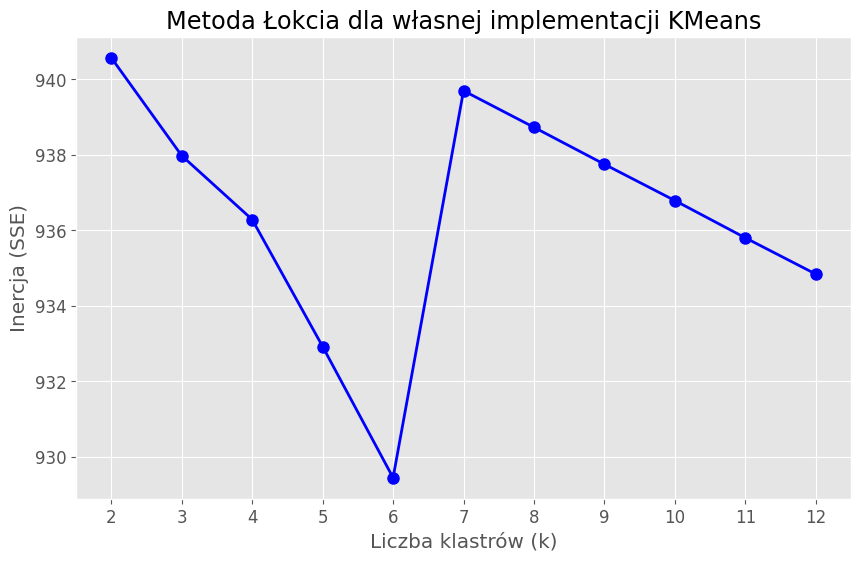

In [4]:
k_values = list(range(2, 13))
inertias = []

print("Uruchamianie metody łokcia dla k od 2 do 12...")
for k in k_values:
    t0 = time.time()
    model = KMeans(n_clusters=k, init='k-means++', random_state=42)
    model.fit(tfidf_matrix)
    inertias.append(model.inertia_)
    print(f"k={k} | Inercja: {model.inertia_:.2f} | Czas: {time.time() - t0:.2f}s")

# Rysowanie wykresu
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Inercja (SSE)')
plt.title('Metoda Łokcia dla własnej implementacji KMeans')
plt.xticks(k_values)
plt.grid(True)
plt.show()

### 🔍 Interpretacja wykresu metody łokcia
Szukamy punktu, w którym spadek inercji gwałtownie spowalnia (zgięcie łokcia).
Wykres pokazuje widoczne złagodzenie spadku w okolicy **k = 4** lub **k = 6**.
Na potrzeby dalszej analizy i optymalnej spójności tematów wybieramy **k = 4**.

## ⚖️ Porównanie wydajności: Własny KMeans vs scikit-learn

Porównamy nasz kod ze zoptymalizowaną biblioteką przemysłową `scikit-learn` dla $k = 4$.

In [5]:
# Własny model
t0 = time.time()
custom_model = KMeans(n_clusters=4, init='k-means++', random_state=42)
custom_model.fit(tfidf_matrix)
t_custom = time.time() - t0

# scikit-learn
t0 = time.time()
sk_model = SKKMeans(n_clusters=4, init='k-means++', n_init=1, max_iter=300, random_state=42)
sk_model.fit(tfidf_matrix)
t_sklearn = time.time() - t0

print("=== WYNIKI PORÓWNANIA ===")
print(f"Własny KMeans:  Czas = {t_custom:.4f}s | Iteracje = {custom_model.n_iter_} | Inercja = {custom_model.inertia_:.4f}")
print(f"sklearn KMeans: Czas = {t_sklearn:.4f}s | Iteracje = {sk_model.n_iter_} | Inercja = {sk_model.inertia_:.4f}")
print(f"Różnica inercji: {abs(custom_model.inertia_ - sk_model.inertia_):.6f}")

=== WYNIKI PORÓWNANIA ===
Własny KMeans:  Czas = 0.0484s | Iteracje = 9 | Inercja = 936.2813
sklearn KMeans: Czas = 1.6833s | Iteracje = 17 | Inercja = 933.8216
Różnica inercji: 2.459661


## 💬 Interpretacja Klastrów (Tematów) — Top Słowa

Ekstrahujemy 10 najistotniejszych słów dla każdego klastra na podstawie centroidów.

In [6]:
top_words = get_top_words(vectorizer, custom_model.cluster_centers_, n_words=10)

print("=== KLUCZOWE SŁOWA DLA TEMATÓW (KLASTRÓW) ===")
for cluster_id, words in top_words.items():
    print(f"\nKlaster {cluster_id}: {', '.join(words)}")
    # Wybór 2 przykładowych dokumentów
    cluster_docs = [documents[i] for i, label in enumerate(custom_model.labels_) if label == cluster_id]
    print("Przykłady tekstów:")
    count = 0
    for doc in cluster_docs:
        clean = doc.strip().replace('\n', ' ')
        if len(clean) > 50 and len(clean) < 300:
            print(f"  - \"{clean[:150]}...\"")
            count += 1
        if count >= 2:
            break

=== KLUCZOWE SŁOWA DLA TEMATÓW (KLASTRÓW) ===

Klaster 0: one, people, god, say, year, would, law, much, think, jesus
Przykłady tekstów:
  - "AE is in Dallas...try 214/241-6060 or 214/241-0055.  Tech support may be on their own line, but one of these should get you started...."
  - "the blood of the lamb.  This will be a hard task, because most cultures used most animals for blood sacrifices. It has to be something related to our ..."

Klaster 1: would, know, like, get, mail, please, anyone, thanks, could, question
Przykłady tekstów:
  - "How about Kirlian imaging ? I believe the FAQ for sci.skeptics (sp?)  has a nice write-up on this. They would certainly be most supportive  on helping..."
  - "There is no notion of heliocentric, or even galacticentric either.    --------------------------------------------------------------------------------..."

Klaster 2: game, well, armenian, muslim, said, people, turkey, time, year, like
Przykłady tekstów:
  - "Well, Dave, I would have to disagre

## 🗺️ Wizualizacja Klastrów w 2D przy użyciu t-SNE

Rzutujemy wysokowymiarowe wektory TF-IDF na płaszczyznę 2D metodą t-SNE w celu wizualizacji klastrów.

Uruchamianie t-SNE (redukcja wymiarowości)...
Rysowanie wykresu t-SNE...


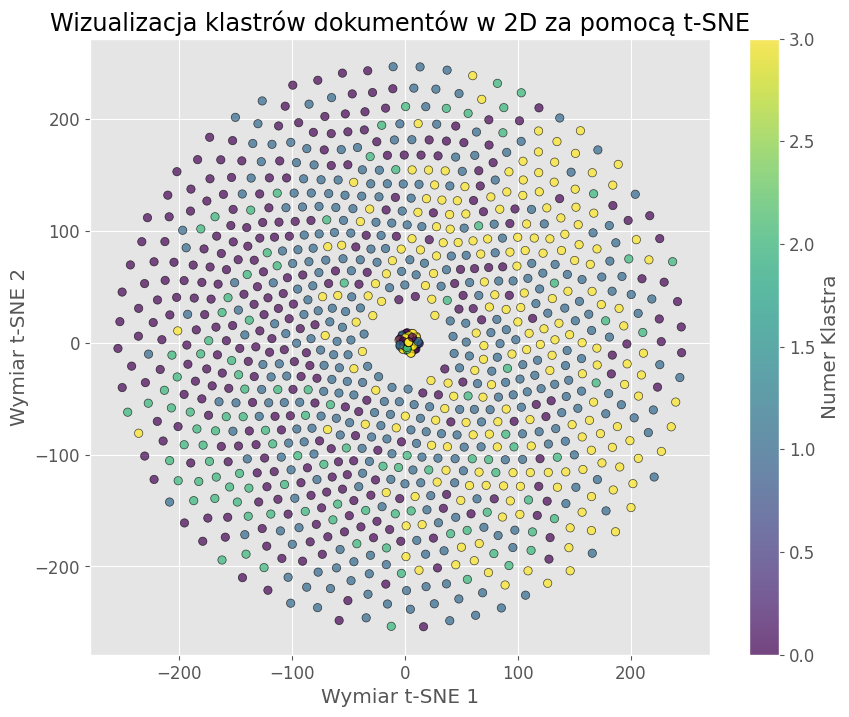

In [9]:
print("Uruchamianie t-SNE (redukcja wymiarowości)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
tfidf_dense = tfidf_matrix.toarray()
tsne_results = tsne.fit_transform(tfidf_dense)

print("Rysowanie wykresu t-SNE...")
plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=custom_model.labels_, cmap='viridis', alpha=0.7, edgecolors='k')
plt.colorbar(scatter, label='Numer Klastra')
plt.title('Wizualizacja klastrów dokumentów w 2D za pomocą t-SNE')
plt.xlabel('Wymiar t-SNE 1')
plt.ylabel('Wymiar t-SNE 2')
plt.grid(True)
plt.show()

## ⚠️ Krytyczna Analiza Ograniczeń i Wnioski

1. **Inicjalizacja centroidów**:
   - Algorytm KMeans jest wrażliwy na początkowe położenie centroidów. Użycie algorytmu `k-means++` pomaga wybrać optymalne centroidy na starcie, redukując ryzyko utknięcia w minimach lokalnych.
2. **Metoda łokcia**:
   - Analiza wykresu SSE nie zawsze daje jednoznaczną odpowiedź na pytanie o optymalne $k$. Często konieczna jest weryfikacja ekspercka (czytanie słów kluczowych).
3. **Metoda t-SNE**:
   - Posiada wysoką złożoność obliczeniową $O(N^2)$ i jest wrażliwa na hiperparametr perplexity. Nie gwarantuje zachowania globalnych odległości.
4. **Reprezentacja TF-IDF**:
   - Model Bag of Words ignoruje kolejność słów i relacje semantyczne (synonimy), co stanowi główne ograniczenie reprezentacji.